In [37]:
from pathlib import Path
import sys

import torch
import numpy as np
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import TUDataset

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import pytorch_to_networkx, networkx_to_igraph
from src.graph_analysis import count_deg_moments
from src.generate_datasets import generate_graph
from notebooks.visualization_utils import plot_graph, plot_annd

In [38]:
DATASET = "DHFR"
IDX = 5

dataset = TUDataset(root=PROJECT_ROOT / 'data', name=DATASET)
GRAPH = pytorch_to_networkx(dataset[IDX])

Original Graph Assortativity: -0.3553


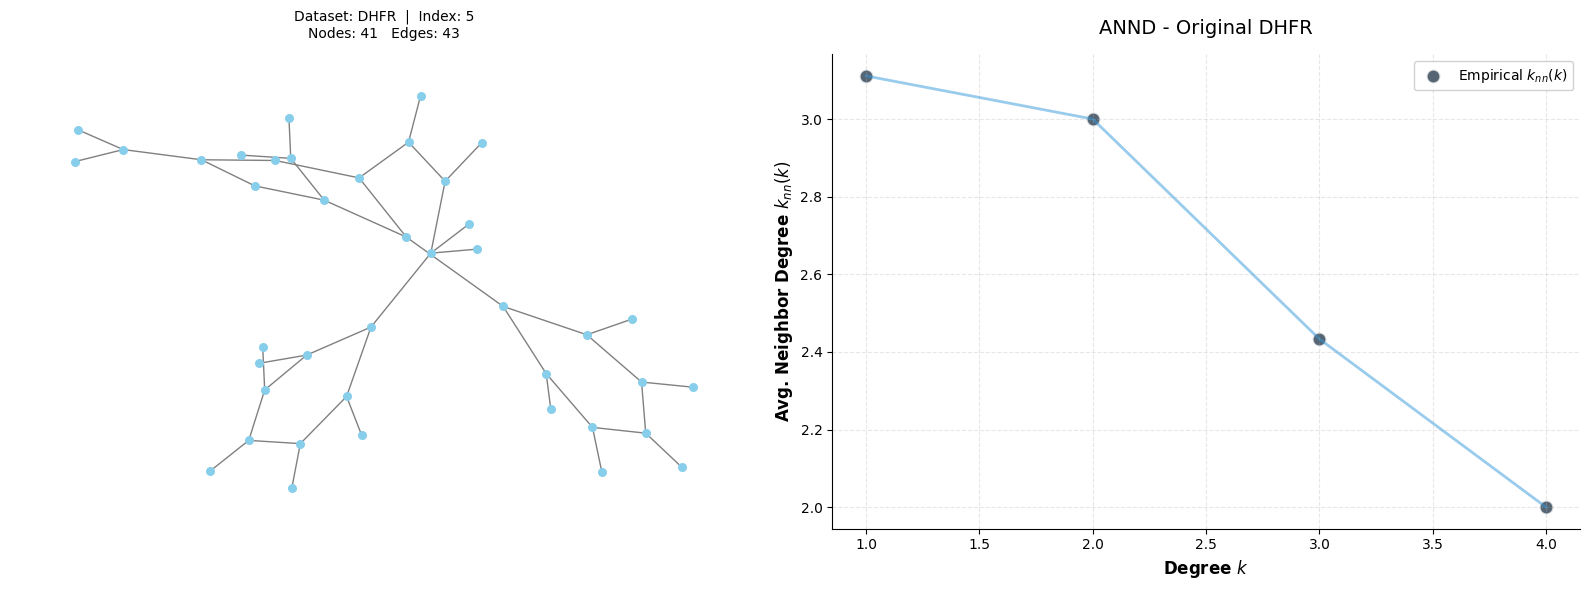

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_graph(graph=GRAPH, ax=ax1, dataset_name=DATASET, graph_index=IDX)
plot_annd(graph=GRAPH, ax=ax2, title=f"ANND - Original {DATASET}")

# Calculate and print assortativity
assortativity = nx.degree_assortativity_coefficient(GRAPH)
print(f"Original Graph Assortativity: {assortativity:.4f}")

plt.tight_layout()
plt.show()

Synthetic Graph Assortativity: -0.0199


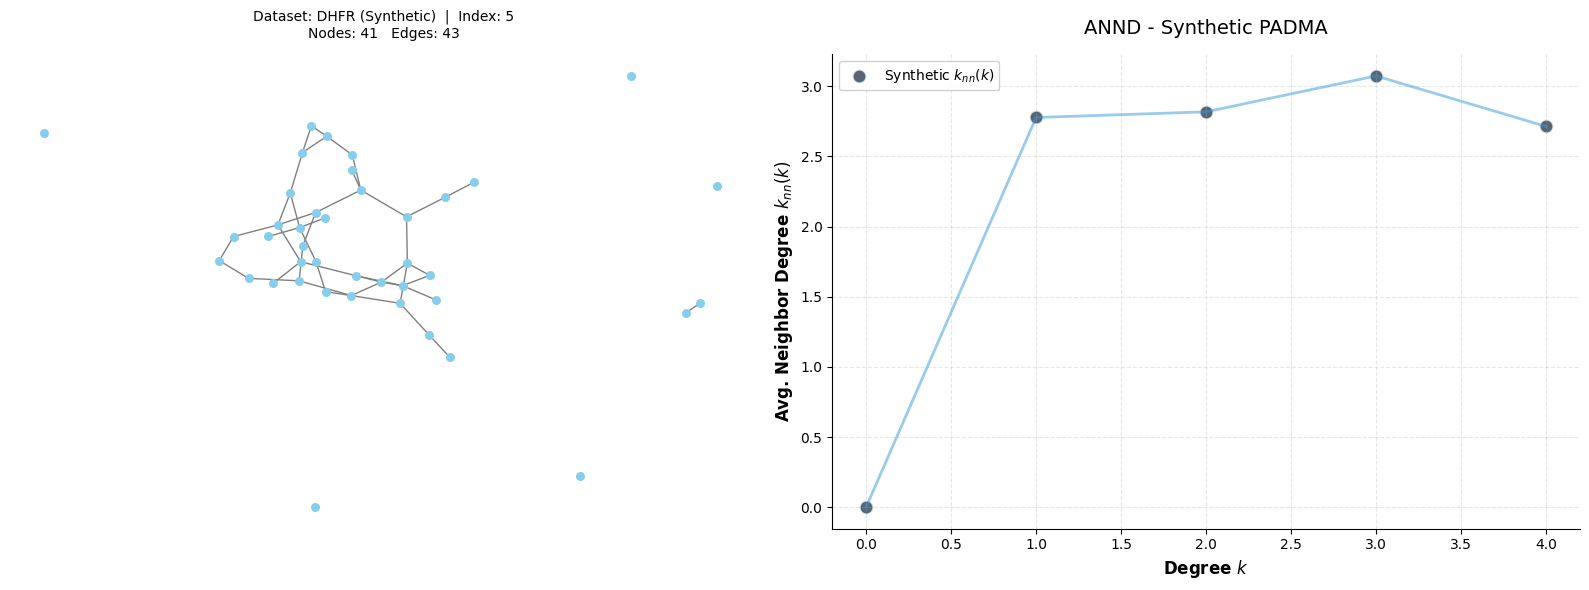

In [40]:
# Prepare target statistics
ig_graph = networkx_to_igraph(GRAPH)
target_stats = {
    "n_nodes": GRAPH.number_of_nodes(),
    "n_edges": GRAPH.number_of_edges(),
    "normalized_degree_moments": count_deg_moments(ig_graph).tolist()
}

# Generate synthetic graph
rng = np.random.default_rng(seed=42)
GRAPH_SYNTH = generate_graph(target_stats, method="padma", rng=rng)

# Plot synthetic results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_graph(graph=GRAPH_SYNTH, ax=ax1, dataset_name=f"{DATASET} (Synthetic)", graph_index=IDX)
plot_annd(graph=GRAPH_SYNTH, ax=ax2, title=f"ANND - Synthetic PADMA", label='Synthetic $k_{nn}(k)$')

# Calculate and print assortativity
assortativity_synth = nx.degree_assortativity_coefficient(GRAPH_SYNTH)
print(f"Synthetic Graph Assortativity: {assortativity_synth:.4f}")

plt.tight_layout()
plt.show()